# VEP DNA Pipeline

## Install core dependencies

- Each model run in the VEP DNA pipeline requires slightly different dependencies. 
- While `vep_pipeline` can theoretically run multiple models in a single python session, it's more practical to maintain
separate conda environments and activate the model's respective environemnt before running `vep_pipeline` on that model.
- See the folder *conda/* for different conda env yamls for each model. To install, just run conda env `create -f <path/to/file.yml`>.


Nevertheless, here are the core dependencies that the pipeline always needs to run `vep_pipeline` (if the conda yaml does not already install them for you). 

The following examples use only chromosome 22 in the Geuvadis collection from 1000 Genomes Project (452 individals).

In [ ]:
# To install GenVarLoader
!conda install bioconda::pgenlib -y
!pip install git+https://github.com/mcvickerlab/GenVarLoader.git

# To install xarray
!conda install conda-forge::xarray conda-forge::zarr -y

In [45]:
%load_ext autoreload
%autoreload 2

import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True
    
import pandas as pd
import polars as pl
import seqpro as sp
import numpy as np
import pooch
from tqdm import tqdm
from pathlib import Path
from tempfile import TemporaryDirectory
import genvarloader as gvl

# Local code
import src.genvarloader as GVL
import src.vep_pipeline as vp
import src.utils as utils
import src.clinvar as cv

# Set environment variable to suppress datetime warnings
os.environ['PYTHONWARNINGS'] = 'ignore::DeprecationWarning:jupyter_client.session'
import warnings
warnings.filterwarnings(action="ignore", message=r"datetime.datetime.utcnow")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Create GVL database

## Download population data

In [6]:
# GRCh38 chromosome 22 sequence
reference = pooch.retrieve(
    url="https://ftp.ensembl.org/pub/release-112/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.22.fa.gz",
    known_hash="sha256:974f97ac8ef7ffae971b63b47608feda327403be40c27e391ee4a1a78b800df5",
    progressbar=True,
)
if not Path(f"{reference[:-3]}.bgz").exists():
    !gzip -dc {reference} | bgzip > {reference[:-3]}.bgz
reference = reference[:-3] + ".bgz"

# PLINK 2 files
variants = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pgen",
    known_hash="md5:31aba970e35f816701b2b99118dfc2aa",
    progressbar=True,
    fname="1kGP.chr22.pgen",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.psam",
    known_hash="md5:eefa7aad5acffe62bf41df0a4600129c",
    progressbar=True,
    fname="1kGP.chr22.psam",
)
pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/1kGP.chr22.pvar",
    known_hash="md5:5f922af91c1a2f6822e2f1bb4469d12b",
    progressbar=True,
    fname="1kGP.chr22.pvar",
)

# BED
bed_path = pooch.retrieve(
    url="doi:10.5281/zenodo.13656224/chr22_egenes.bed",
    known_hash="md5:ccb55548e4ddd416d50dbe6638459421",
    progressbar=True,
)


## Create BED file

This BED file is based on the coordinates of the UTR variants we're planning on injecting, surrounded by 500kb windows.

In [126]:
bed = pl.read_csv(
    "data/UTR/clinvar_utr_snv.bed.gz",
    schema_overrides={
        'chrom': pl.Utf8,
        'chromStart': pl.Int64,
        'chromEnd': pl.Int64,
        'score': pl.Float64
    },
    separator='\t'
).drop_nulls(subset=['ALT'])
# bed = gvl.read_bedlike("data/UTR/snps_500kb_windows.bed")
print(bed.shape)
bed.head()

(13771, 21)


chrom,chromStart,chromEnd,name,score,REF,ALT,MC_id,MC_term,AF_ESP,AF_EXAC,AF_TGP,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNVC,CLNVCSO,GENEINFO
str,i64,i64,str,f64,str,str,str,str,f64,f64,f64,i64,str,str,str,str,str,str,str,str
"""1""",1013541,1013542,"""chr1:1013541-1013542_TC""",2.0,"""T""","""C""","""SO:0001623""","""5_prime_UTR_variant""",0.88579,null,0.90315,1175251,"""MedGen:C3661900|MONDO:MONDO:00…","""not_provided|Mendelian_suscept…","""NC_000001.11:g.1013541T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""ISG15:9636"""
"""1""",1055000,1055001,"""chr1:1055000-1055001_CT""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",0.34176,0.33342,0.34345,249353,"""MedGen:CN169374|MONDO:MONDO:00…","""not_specified|Congenital_myast…","""NC_000001.11:g.1055000C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790"""
"""1""",1055037,1055038,"""chr1:1055037-1055038_TC""",2.0,"""T""","""C""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.38399,1282674,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055037T>C""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790"""
"""1""",1055137,1055138,"""chr1:1055137-1055138_CT""",2.0,"""C""","""T""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.91793,1175253,"""MONDO:MONDO:0014052,MedGen:C38…","""Congenital_myasthenic_syndrome…","""NC_000001.11:g.1055137C>T""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790"""
"""1""",1055153,1055154,"""chr1:1055153-1055154_GA""",2.0,"""G""","""A""","""SO:0001624""","""3_prime_UTR_variant""",null,null,0.12181,1282812,"""MedGen:C3661900""","""not_provided""","""NC_000001.11:g.1055153G>A""","""criteria_provided,_multiple_su…","""Benign""","""single_nucleotide_variant""","""SO:0001483""","""AGRN:375790"""


## Create GVL database

In [127]:
tmp_dir = TemporaryDirectory(suffix=".gvl")
ds_path = tmp_dir.name

bed_chrom = bed.filter(pl.col('chrom')=='22')[:20]
gvl.write(
    path=ds_path,
    bed=gvl.with_length(bed_chrom, 2**18),  # change region length to 131,072 bp
    variants=variants,
    overwrite=True,
)

/home/schilder/.conda/envs/flashzoi/lib/python3.12/tempfile.py:940: ResourceWarning: Implicitly cleaning up <TemporaryDirectory '/tmp/tmprohqq59e.gvl'>
  _warnings.warn(warn_message, ResourceWarning)
2025-05-20 00:26:04.431 | INFO     | genvarloader._dataset._write:write:76 - Writing dataset to /tmp/tmpilj2tx_u.gvl
2025-05-20 00:26:04.432 | INFO     | genvarloader._dataset._write:write:83 - Found existing GVL store, overwriting.
2025-05-20 00:26:04.438 | INFO     | genoray._pgen:_read_index:1078 - Loading genoray index.
2025-05-20 00:26:04.779 | INFO     | genvarloader._dataset._write:write:148 - Using 451 samples.
2025-05-20 00:26:04.780 | INFO     | genvarloader._dataset._write:write:154 - Writing genotypes.


  0%|          | 0/20 [00:00<?, ? region/s]

2025-05-20 00:26:05.988 | INFO     | genvarloader._dataset._write:write:178 - Finished writing.


## Import GVL database

In [128]:
ds = (
    gvl.Dataset.open(ds_path, reference=reference)
    .with_seqs("haplotypes")
    .with_len(2**18)
)

2025-05-20 00:26:07.771 | INFO     | genvarloader._dataset._impl:open:206 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-05-20 00:26:07.792 | INFO     | genvarloader._dataset._reconstruct:from_path:204 - Loading variant data.
2025-05-20 00:26:07.812 | INFO     | genvarloader._dataset._impl:open:293 - Opened dataset:
GVL store at /tmp/tmpilj2tx_u.gvl
Is subset: False
# of regions: 20
# of samples: 451
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None



## Run VEP

Initialize xarray Dataset.

In [133]:
# Convert BED to sites
sites = cv.bed_to_sites(bed_chrom)
# sites = gvl.sites_vcf_to_table('./data/UTR/filtered_chr22_snps.vcf')

# Import sites_ds
site_ds = gvl.DatasetWithSites(ds, sites) 
site_ds

In [ ]:
# Add the site_name column
GVL.add_site_name(site_ds)

# Create path for results file
results_dir = os.path.join(os.path.expanduser('~'), 
                           "projects","data")
cohort = "1000_Genomes_on_GRCh38"
variant_set = "ClinVar_UTR"
chrom = "chr22"
zarr_path = os.path.join(results_dir,
                         cohort,
                         variant_set,
                         f"{chrom}.zarr")
print(zarr_path)
os.makedirs(os.path.dirname(zarr_path), exist_ok=True)

# Initialize or load the dataset
all_models = ["flashzoi", "evo2_7b", "spliceai_mm"]
ds_results = vp.init_or_load_xarray_dataset(
    zarr_path=zarr_path,
    all_models=all_models, 
    site_ds=site_ds, 
    force=False
)
ds_results

/home/schilder/projects/data/1000_Genomes_on_GRCh38/ClinVar_UTR/chr22.zarr
Initializing new dataset at /home/schilder/projects/data/1000_Genomes_on_GRCh38/ClinVar_UTR/chr22.zarr


Initializing data arrays:   0%|          | 0/3 [00:00<?, ?it/s]

Creating xarray dataset with 3 model(s)
Saving xarray dataset to /home/schilder/projects/data/1000_Genomes_on_GRCh38/ClinVar_UTR/chr22.zarr
xarray dataset saved to /home/schilder/projects/data/1000_Genomes_on_GRCh38/ClinVar_UTR/chr22.zarr


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/core/array.py:4257: UserWarning: The dtype `<U7` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/zarr/core/array.p

<xarray.Dataset> Size: 104MB
Dimensions:      (site: 399, sample: 451, ploid: 2, slot: 12)
Coordinates:
  * site         (site) <U27 43kB 'chr22:16953970-17216114_T_C' ... 'chr22:16...
  * sample       (sample) <U7 13kB 'HG00096' 'HG00097' ... 'NA20826' 'NA20828'
  * ploid        (ploid) <U1 8B '0' '1'
  * slot         (slot) <U21 1kB 'VEP' 'VEP_acceptor' ... 'timestamp'
Data variables:
    flashzoi     (site, sample, ploid, slot) object 35MB nan nan ... None None
    evo2_7b      (site, sample, ploid, slot) object 35MB None nan ... None None
    spliceai_mm  (site, sample, ploid, slot) object 35MB nan None ... None None

Populate the `xarray` dataset using the steamlined `vep_pipeline` function.

In [ ]:
import warnings
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message=r"`torch.cuda.amp.autocast\(args\.\.\.\)` is deprecated")

ds_results = vp.vep_pipeline(site_ds=site_ds, 
                           zarr_path=zarr_path,
                           all_models=["flashzoi"], 
                           checkpoint_frequency="site",
                           
                           verbose=True,
                           force=False,
                           sample_limit=50,
                           site_limit=2
                           )

Loading existing results from /home/schilder/projects/data/1000_Genomes_on_GRCh38/ClinVar_UTR/chr22.zarr


Iterating over models:   0%|          | 0/1 [00:00<?, ?it/s]

Iterating over sites:   0%|          | 0/400 [00:00<?, ?it/s]

Iterating over samples:   0%|          | 0/451 [00:00<?, ?it/s]

Iterating over samples:   0%|          | 0/451 [00:00<?, ?it/s]

Get non-null subset of VEP results 

In [173]:
ds_vep =  ds_results.where(ds_results.notnull())
vep_df = ds_vep.to_dataframe().dropna(subset=["flashzoi"]).reset_index()
print(vep_df.shape)
vep_df.head()

(2352, 5)


,site,sample,ploid,slot,flashzoi
0,chr21:25508704-25770848_C_A,HG00096,0,delta_mean,0.000100
1,chr21:25508704-25770848_C_A,HG00096,0,delta_abs_mean,0.000490
2,chr21:25508704-25770848_C_A,HG00096,0,time_total,0.107208
3,chr21:25508704-25770848_C_A,HG00096,0,time_run_vep,0.101199
4,chr21:25508704-25770848_C_A,HG00096,0,output_length,262144.000000


In [174]:
vep_df.groupby("slot").describe()

flashzoi                                          \
                  count           mean       std            min   
slot                                                              
delta_abs_mean    336.0       0.000482  0.000060       0.000381   
delta_mean        336.0       0.000045  0.000060      -0.000092   
len_seq_mut       336.0  262144.000000  0.000000  262144.000000   
len_seq_wt        336.0  262144.000000  0.000000  262144.000000   
output_length     336.0  262144.000000  0.000000  262144.000000   
time_run_vep      336.0       0.099504  0.000521       0.098732   
time_total        336.0       0.104447  0.000887       0.103256   

                                                                            
                          25%            50%            75%            max  
slot                                                                        
delta_abs_mean       0.000447       0.000488       0.000506       0.000636  
delta_mean           0.000013       0.000052       0.000091       0.000166  
len_seq_mut     262144.000000  262144.000000  262144.000000  262144.000000  
len_seq_wt      262144.000000  262144.000000  262144.000000  262144.000000  
output_length   262144.000000  262144.000000  262144.000000  262144.000000  
time_run_vep         0.099194       0.099476       0.099675       0.102096  
time_total           0.103959       0.104314       0.104634       0.110065

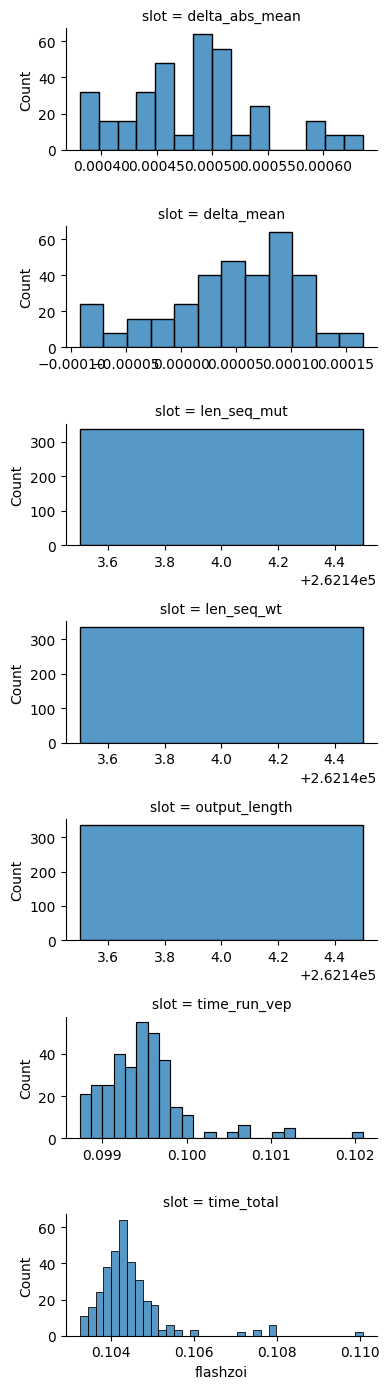

In [175]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with subplots for each slot
g = sns.FacetGrid(vep_df.sort_values("slot"),
                  row="slot", 
                  height=2, aspect=2, 
                  sharex=False, 
                  sharey=False)
g.map_dataframe(sns.histplot, x="flashzoi")
plt.tight_layout()

## Run VEP pipeline for full 1KG dataset

Here we extend the `vep_pipeline` to run on all 2.5K+ individuals in the low-coverage WGS cohort.

This includes all chromosomes (not just chromosome 22).

In [157]:
import src.onekg as og
cohort = "1000_Genomes_on_GRCh38"
variant_set = "clinvar_utr_snv"

# Chrom-specific fasta references: 
# https://ftp.ensembl.org/pub/release-112/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.chromosome.22.fa.gz

# Merged fasta reference
# https://ftp.1000genomes.ebi.ac.uk/vol1/ftp/technical/reference/GRCh38_reference_genome/GRCh38_full_analysis_set_plus_decoy_hla.fa
reference = pooch.retrieve(
    url=og.get_ftp_dict()[cohort]['ref'],
    known_hash=None,
    progressbar=True
)

manifest = og.list_remote_vcf(key=cohort)
chroms = manifest['chrom'].unique().tolist()
chroms.reverse()

# Import bed file
bed = pl.read_csv(
    "data/UTR/clinvar_utr_snv.bed.gz",
    schema_overrides={
        'chrom': pl.Utf8,
        'chromStart': pl.Int64,
        'chromEnd': pl.Int64,
        'score': pl.Float64
    },
    separator='\t'
).drop_nulls(subset=['ALT'])


In [181]:
import warnings
warnings.filterwarnings("ignore", message="The codec `vlen-utf8` is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part in the Zarr format 3 specification")
warnings.filterwarnings("ignore", message=r"`torch.cuda.amp.autocast\(args\.\.\.\)` is deprecated")


all_models = ["flashzoi", "evo2_7b", "spliceai_mm"][:1]
window_len = 2**18
limit_regions = None
limit_chroms = None
sample_limit=None
site_limit=None
force_gvl = False
force_vep = 1 # 2

# Iterate over chromosomes
for chrom in tqdm(chroms[1:limit_chroms],
                  desc="Iterating over chromosomes"):
    
    # Create storage directory
    results_dir = os.path.join(os.path.expanduser('~'), 
                               "projects","data",cohort,variant_set)
    
    # Download VCF files
    vcf_paths = og.download_vcfs(manifest=manifest.loc[manifest['chrom']==chrom,:])
    variants = vcf_paths[f"chr{chrom.replace('chr', '')}_vcf"]
    
    # Create GVL database name
    ds_path = os.path.join(results_dir, f"{chrom}.gvl")

    # Create GVL database
    bed_chrom = bed.filter(pl.col('chrom').str.replace("chr", "")==chrom.replace("chr", ""))
    if bed_chrom.height == 0:
        print(f"No variants found for chromosome {chrom}")
        continue
    
    if not os.path.exists(ds_path) or force_gvl:
        gvl.write(
            path=ds_path,
            bed=gvl.with_length(bed_chrom[:limit_regions], window_len),
            variants=variants,
            overwrite=True,
        )
    # Import GVL database
    ds = (
        gvl.Dataset.open(ds_path, reference=reference)
        .with_seqs("haplotypes")
        .with_len(window_len)
    )

    # Import sites_ds
    # Convert BED to sites
    sites_chrom = cv.bed_to_sites(bed_chrom)
    site_ds = gvl.DatasetWithSites(ds, sites_chrom) 
    # Add the site_name column
    GVL.add_site_name(site_ds)

    # Create path for results file
    zarr_path = os.path.join(results_dir,
                             f"{chrom}.zarr") 
    
    # Run VEP pipeline
    ds_results = vp.vep_pipeline(site_ds=site_ds, 
                            zarr_path=zarr_path,
                            all_models=all_models, 
                            checkpoint_frequency="site",
                            
                            verbose=True,
                            force=force_vep,
                            sample_limit=sample_limit,
                            site_limit=site_limit
                            )


/home/schilder/.conda/envs/flashzoi/lib/python3.12/site-packages/IPython/extensions/deduperreload/deduperreload.py:290: DeprecationWarning: ast.Ellipsis is deprecated and will be removed in Python 3.14; use ast.Constant instead
  elif not isinstance(ast_elt, (ast.Ellipsis, ast.Pass)):
Iterating over chromosomes:   0%|          | 0/2 [00:00<?, ?it/s]

2025-05-20 01:33:30.369 | INFO     | genvarloader._dataset._impl:open:206 - Loading reference genome into memory. This typically has a modest memory footprint (a few GB) and greatly improves performance.
2025-05-20 01:33:30.387 | INFO     | genvarloader._dataset._reconstruct:from_path:204 - Loading variant data.
2025-05-20 01:33:30.407 | INFO     | genvarloader._dataset._impl:open:293 - Opened dataset:
GVL store at /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.gvl
Is subset: False
# of regions: 20
# of samples: 2548
Output length: ragged
Jitter: 0 (max: 0)
Deterministic: True
Sequence type: reference [haplotypes] annotated variants
Active tracks: None
Tracks available: None



Loading existing results from /home/schilder/projects/data/1000_Genomes_on_GRCh38/clinvar_utr_snv/chr22.zarr


Iterating over models:   0%|          | 0/1 [00:00<?, ?it/s]

Iterating over sites:   0%|          | 0/720 [00:00<?, ?it/s]

...

Iterating over samples:   0%|          | 0/2548 [00:00<?, ?it/s]

Iterating over samples:   0%|          | 0/2548 [00:00<?, ?it/s]

Iterating over samples:   0%|          | 0/2548 [00:00<?, ?it/s]

Iterating over samples:   0%|          | 0/2548 [00:00<?, ?it/s]

Iterating over chromosomes: 100%|██████████| 2/2 [00:38<00:00, 19.06s/it]


## Get the unique haplotypes

In [ ]:
import awkward as ak
import numba as nb
import numpy as np
from attrs import define
from seqpro._ragged import Ragged
from genvarloader._dataset._reconstruct import Haps, V_IDX_TYPE
from genvarloader._dataset._impl import Dataset


@define
class UniqueInfo:
    """Class to store unique genotypes."""

    # sample, ploidy => ds[region_idx, sample_idx][ploid_idx] (ploidy length) => unique haplotype sequence
    first_idxs: Ragged[np.void]
    """First haplotype indices. Shape: (n_regions, ~n_unique)"""
    inverse_idxs: ak.Array  # total elements = regions * samples * ploidy
    """Inverse indices. Shape: (n_regions, ~n_unique, ~n_haps)"""
    counts: Ragged[np.uint32]
    """Counts. Shape: (n_regions, ~n_unique)"""

    @property
    def n_regions(self) -> int:
        """Number of regions."""
        return self.first_idxs.shape[0]

    @property
    def n_unique(self):
        """Number of unique genotypes."""
        return self.first_idxs.lengths


def unique(dataset: Dataset) -> UniqueInfo:
    if not isinstance(dataset._seqs, Haps):
        raise ValueError(
            "Dataset must have genotypes/haplotypes to compute unique haplotype information."
        )

    genos = dataset._seqs.genotypes
    regions = dataset._full_regions
    out_len = dataset.output_length
    first_idxs, inverse_idxs, counts = _unique_genotypes(
        genos.data, genos.offsets, regions, out_len
    )


@nb.njit(nogil=True, cache=True)
def _unique_genotypes(v_idxs, v_offsets, regions, out_len): 
    pass